# Denoise Autoencoders

In [ ]:
import numpy as np
import torch
import torchaudio

import matplotlib.pyplot as plt
from IPython.display import display, Audio

from dataset_generation import generate_waveform_pairs
from denoise_spec import DenoiseSpecAutoencoder

## Pomoćne funkcije

In [2]:
def waveforms_to_specs_with_saved_norm(
    clean_waveforms,
    noisy_waveforms,
    spec_min,
    spec_max,
    n_fft,
    win_length,
    hop_length,
):
    transform = torchaudio.transforms.Spectrogram(
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        power=2.0,
    )

    clean_specs = transform(clean_waveforms)
    noisy_specs = transform(noisy_waveforms)

    clean_specs = torch.log1p(clean_specs)
    noisy_specs = torch.log1p(noisy_specs)

    clean_specs = (clean_specs - spec_min) / (spec_max - spec_min + 1e-8)
    noisy_specs = (noisy_specs - spec_min) / (spec_max - spec_min + 1e-8)

    clean_specs = torch.clamp(clean_specs, 0.0, 1.0)
    noisy_specs = torch.clamp(noisy_specs, 0.0, 1.0)

    return clean_specs, noisy_specs

In [90]:
def plot_three_spectrograms(S_clean, S_noisy, S_reconstructed):
    specs = [np.asarray(S_clean), np.asarray(S_noisy), np.asarray(S_reconstructed)]
    titles = ["Original", "Dodan šum", "Rekonstrukcija"]

    cmap = "turbo" 

    all_values = np.concatenate([
        S_clean.ravel(),
        S_noisy.ravel(),
        S_reconstructed.ravel()
    ])

    vmin = np.percentile(all_values, 5)
    vmax = np.percentile(all_values, 97)

    fig, axes = plt.subplots(1, 3, figsize=(8, 4), dpi=200, sharey=True)

    for ax, S, title in zip(axes, specs, titles):
        im = ax.imshow(
            S,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("Uzorak")
        ax.set_box_aspect(1)

    axes[0].set_ylabel("Frekvencije")
    plt.tight_layout()
    plt.show()

In [61]:
def add_gaussian_noise(x, noise_std=0.15, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    noise = rng.normal(0.0, noise_std, size=x.shape).astype(np.float32)
    return (x + noise).astype(np.float32)

# Test

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(
    "denoise_autoencoder.pt",
    map_location=device,
)

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]

config = checkpoint["config"]

sample_rate = config["sample_rate"]
num_samples = config["num_samples"]

n_fft = config["n_fft"]
win_length = config["win_length"]
hop_length = config["hop_length"]

mask_floor = config["mask_floor"]

spec_min = checkpoint["spec_min"]
spec_max = checkpoint["spec_max"]

model = DenoiseSpecAutoencoder(mask_floor=mask_floor).to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

DenoiseMaskAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)

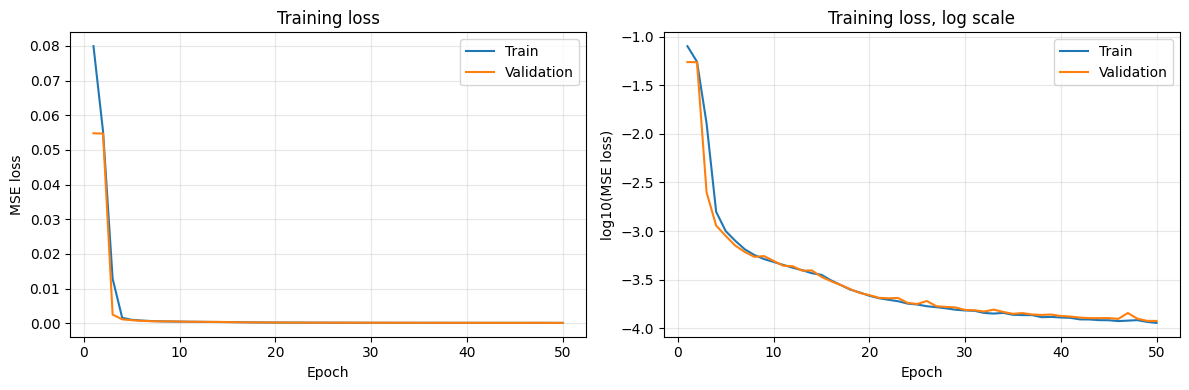

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = np.arange(1, len(train_losses) + 1)

axes[0].plot(epochs, train_losses, label="Train")
axes[0].plot(epochs, val_losses, label="Validation")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, np.log10(train_losses), label="Train")
axes[1].plot(epochs, np.log10(val_losses), label="Validation")
axes[1].set_title("Training loss, log scale")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("log10(MSE loss)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
regimes = ["single_note", "multi_note", "chord"]

examples = {}

for regime in regimes:
    clean_waveforms, noisy_waveforms = generate_waveform_pairs(
        num_examples=1,
        sample_rate=sample_rate,
        num_samples=num_samples,
        regime=regime,
        min_snr_db=15.0,
        max_snr_db=30.0,
    )

    clean_specs, noisy_specs = waveforms_to_specs_with_saved_norm(
        clean_waveforms=clean_waveforms,
        noisy_waveforms=noisy_waveforms,
        spec_min=spec_min,
        spec_max=spec_max,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
    )

    examples[regime] = {
        "clean_waveform": clean_waveforms,
        "noisy_waveform": noisy_waveforms,
        "clean_spec": clean_specs,
        "noisy_spec": noisy_specs,
    }

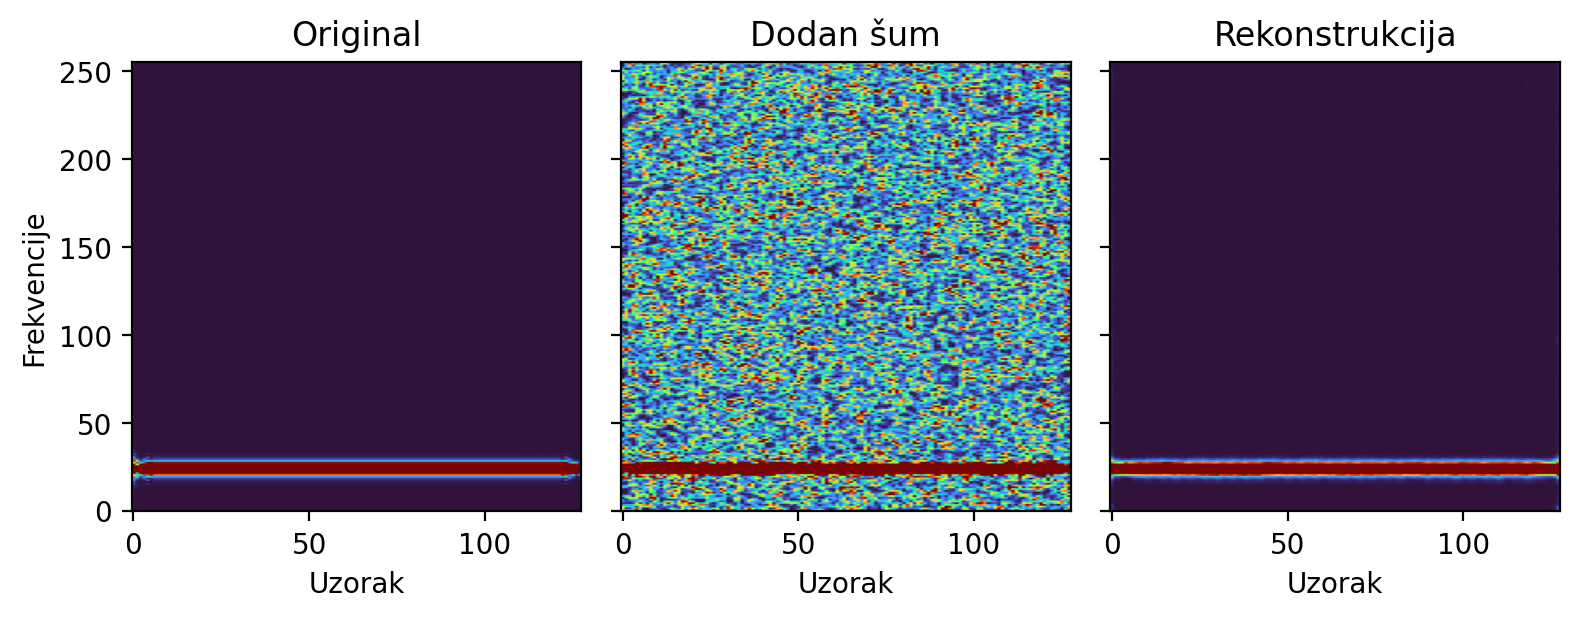

In [93]:
regime = "single_note"
clean = examples[regime]["clean_spec"]
noisy = examples[regime]["noisy_spec"]

with torch.no_grad():
    z = model.encoder(noisy)
    denoised = model.decoder(z)

plot_three_spectrograms(clean[0, 0], noisy[0, 0], denoised[0, 0])


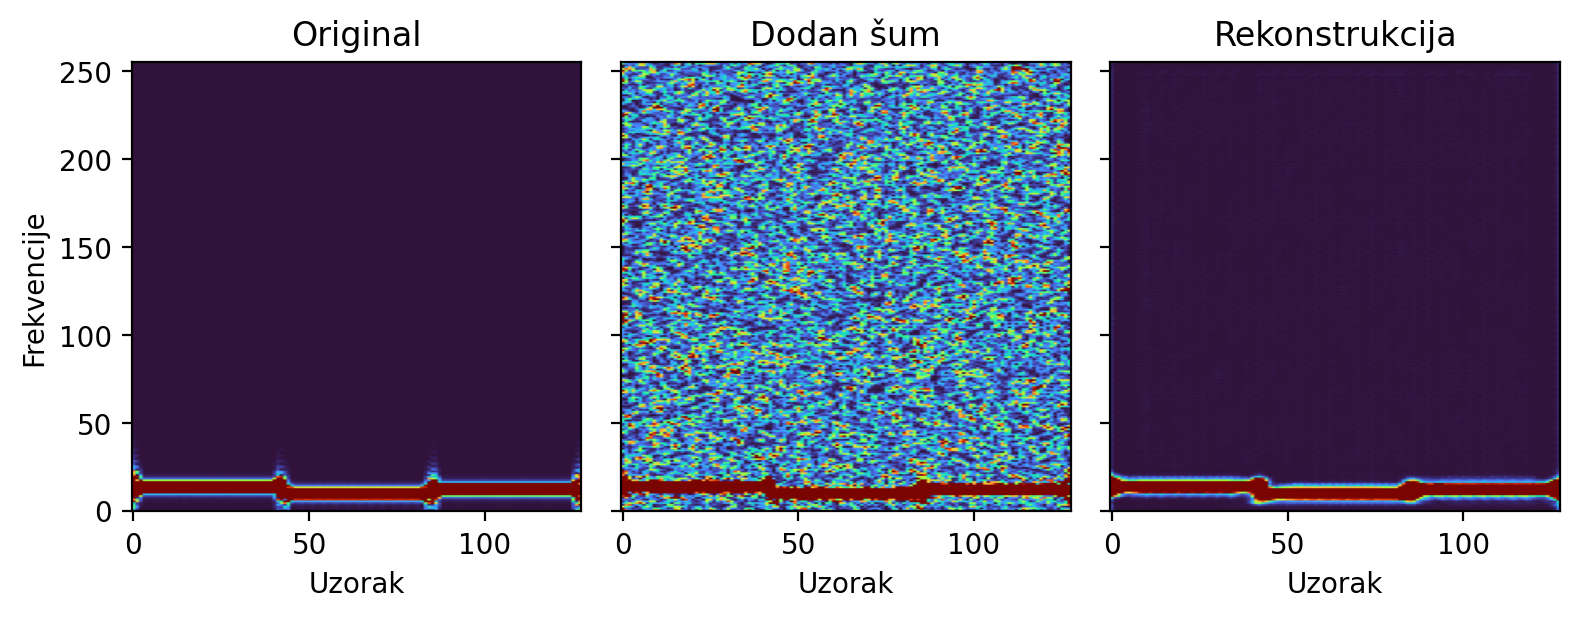

In [94]:
regime = "multi_note"
clean = examples[regime]["clean_spec"]
noisy = examples[regime]["noisy_spec"]

with torch.no_grad():
    z = model.encoder(noisy)
    denoised = model.decoder(z)

plot_three_spectrograms(clean[0, 0], noisy[0, 0], denoised[0, 0])


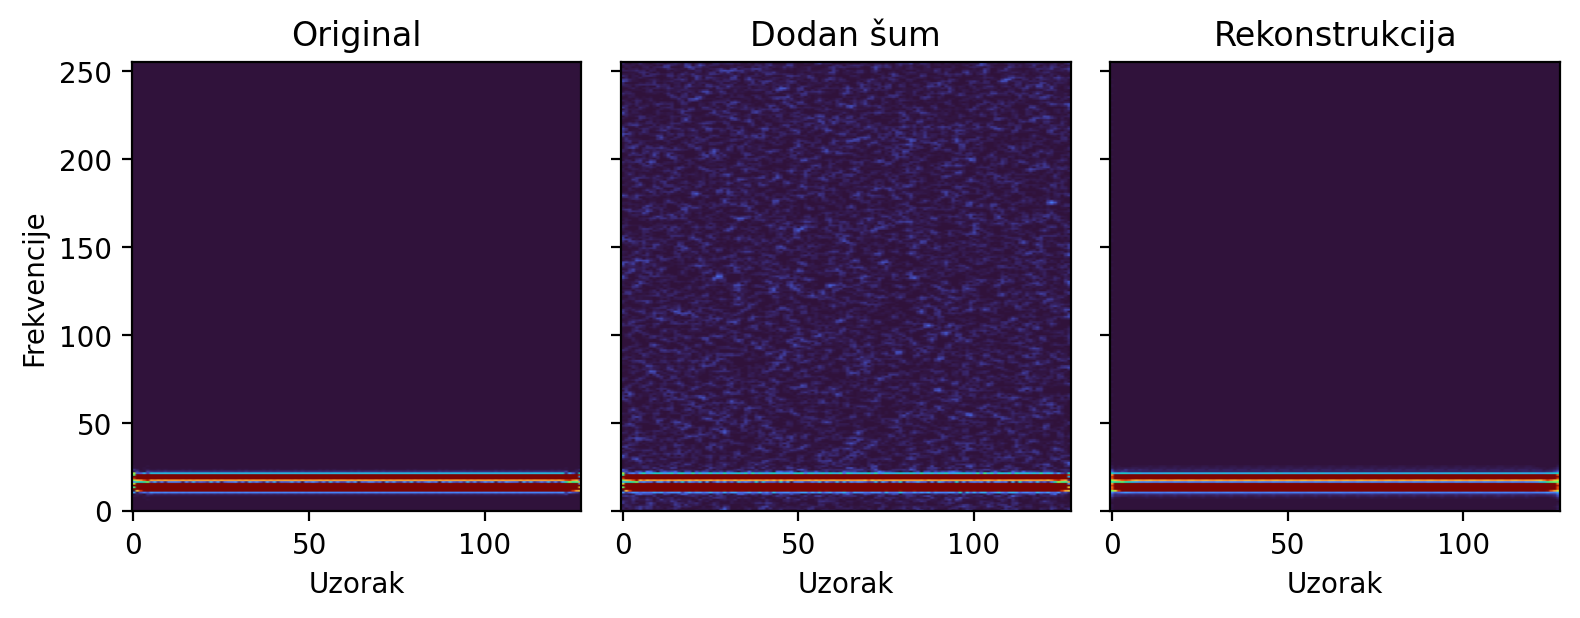

In [95]:
regime = "chord"
clean = examples[regime]["clean_spec"]
noisy = examples[regime]["noisy_spec"]

with torch.no_grad():
    z = model.encoder(noisy)
    denoised = model.decoder(z)

plot_three_spectrograms(clean[0, 0], noisy[0, 0], denoised[0, 0])


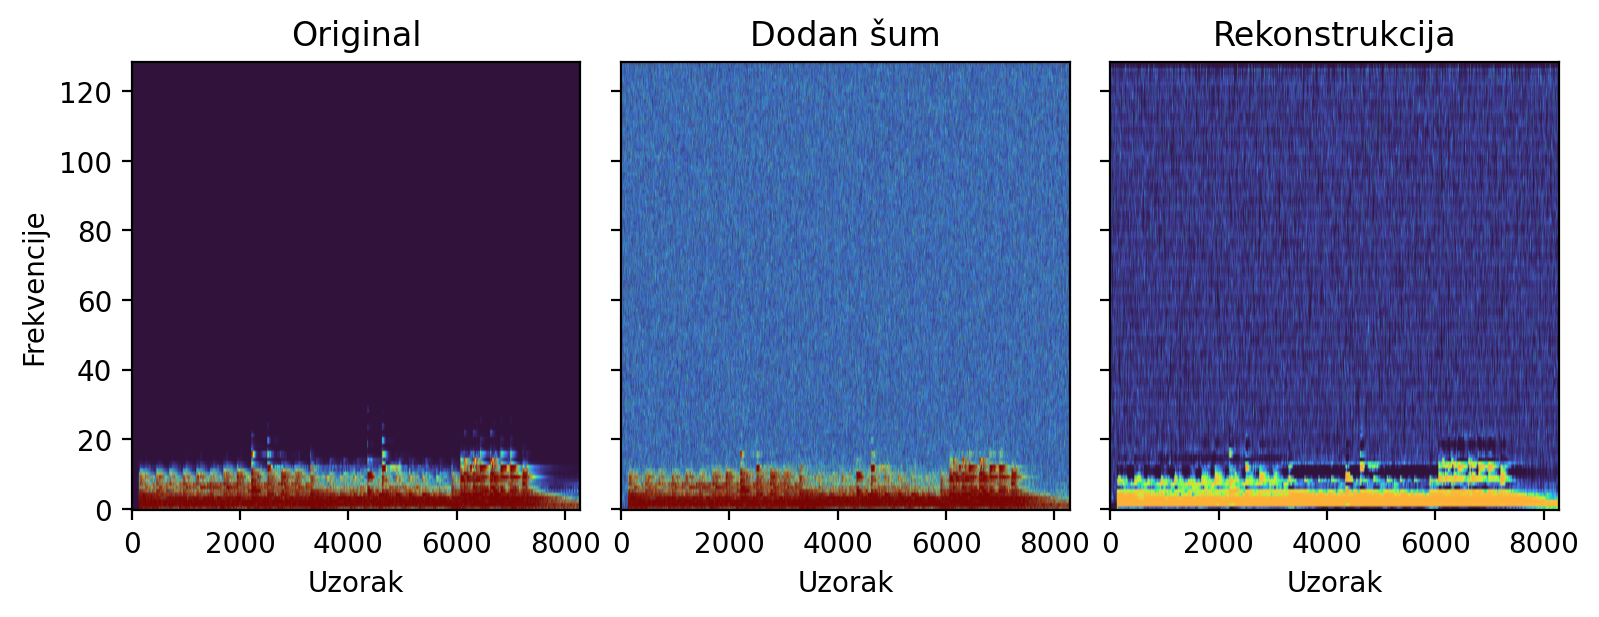

In [ ]:
waveform, sample_rate = torchaudio.load("../data/ennio.mp3")

waveform = waveform.mean(dim=0, keepdim=True)

waveform = waveform / (waveform.abs().max() + 1e-8)

noise_std = 0.05
noisy_waveform = waveform + noise_std * torch.randn_like(waveform)
noisy_waveform = torch.clamp(noisy_waveform, -1.0, 1.0)

spec_transform = torchaudio.transforms.Spectrogram(
    n_fft=256,
    hop_length=128,
    power=2.0,
)

S_clean = spec_transform(waveform)
S_noisy = spec_transform(noisy_waveform)

S_clean = torch.log1p(S_clean)
S_noisy = torch.log1p(S_noisy)

_, H, W = S_noisy.shape   # S_noisy shape: (1, freq_bins, time_frames)

pad_H = (-H) % 4
pad_W = (-W) % 4

S_noisy_padded = torch.nn.functional.pad(
    S_noisy,
    pad=(0, pad_W, 0, pad_H),  # pad width first, then height
    mode="constant",
    value=0.0,
)
x = S_noisy_padded.unsqueeze(0)

model.eval()
with torch.no_grad():
    S_reconstructed = model(x)

S_reconstructed = S_reconstructed[:, :, :H, :W]

S_clean_plot = S_clean.squeeze().cpu().numpy()
S_noisy_plot = S_noisy.squeeze().cpu().numpy()
S_reconstructed_plot = S_reconstructed.squeeze().cpu().numpy()

plot_three_spectrograms(
    S_clean_plot,
    S_noisy_plot,
    S_reconstructed_plot,
)